In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ssd_data.csv")

print("Shape:", df.shape)

print("\nColumn types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["health_status"].value_counts())

df.describe()

Shape: (8000, 8)

Column types:
temperature       float64
wear_level        float64
power_on_hours      int64
write_cycles        int64
ECC_error_rate    float64
bad_blocks          int64
RUL                 int64
health_status         str
dtype: object

Missing values:
temperature       0
wear_level        0
power_on_hours    0
write_cycles      0
ECC_error_rate    0
bad_blocks        0
RUL               0
health_status     0
dtype: int64

Label distribution:
health_status
Warning     3978
Healthy     3542
Critical     480
Name: count, dtype: int64


,temperature,wear_level,power_on_hours,write_cycles,ECC_error_rate,bad_blocks,RUL
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,44.985675,50.346500,24828.588500,50462.600375,0.019859,2.022875,5540.887625
std,10.009371,28.914339,14414.987881,28952.180109,0.020146,1.437223,2352.476811
min,20.000000,0.000000,102.000000,510.000000,0.000000,0.000000,233.000000
25%,38.200000,25.300000,12287.500000,25151.500000,0.005800,1.000000,3519.000000
50%,44.900000,50.500000,24407.000000,50751.000000,0.013800,2.000000,5539.000000
75%,51.700000,75.700000,37306.000000,75741.750000,0.027400,3.000000,7541.000000
max,80.000000,100.000000,49993.000000,99993.000000,0.184100,9.000000,10000.000000


In [ ]:
## Initial Data Understanding

- Dataset contains 8000 SSD samples with 8 features.
- No missing values detected.
- Target variable (health_status) has class imbalance:
  Critical cases are significantly fewer than Healthy and Warning.

## Feature Insights

- Temperature ranges from 20°C to 80°C with a mean of ~45°C.
- Wear level is evenly distributed from 0 to 100, making it a strong predictive feature.
- ECC error rate and bad blocks are likely strong indicators of SSD degradation.
- Power on hours and write cycles capture SSD aging patterns.
- RUL provides a continuous measure of remaining life, suitable for regression tasks.

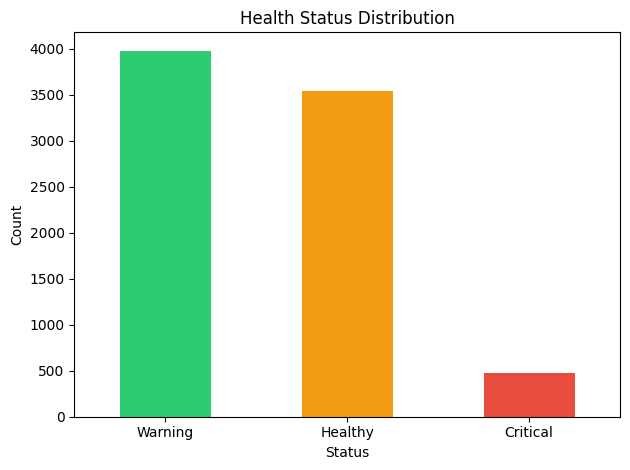

In [7]:
df["health_status"].value_counts().plot(
    kind="bar",
    color=["#2ECC71", "#F39C12", "#E74C3C"]
)

plt.title("Health Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../reports/class_distribution.png", dpi=150)
plt.show()

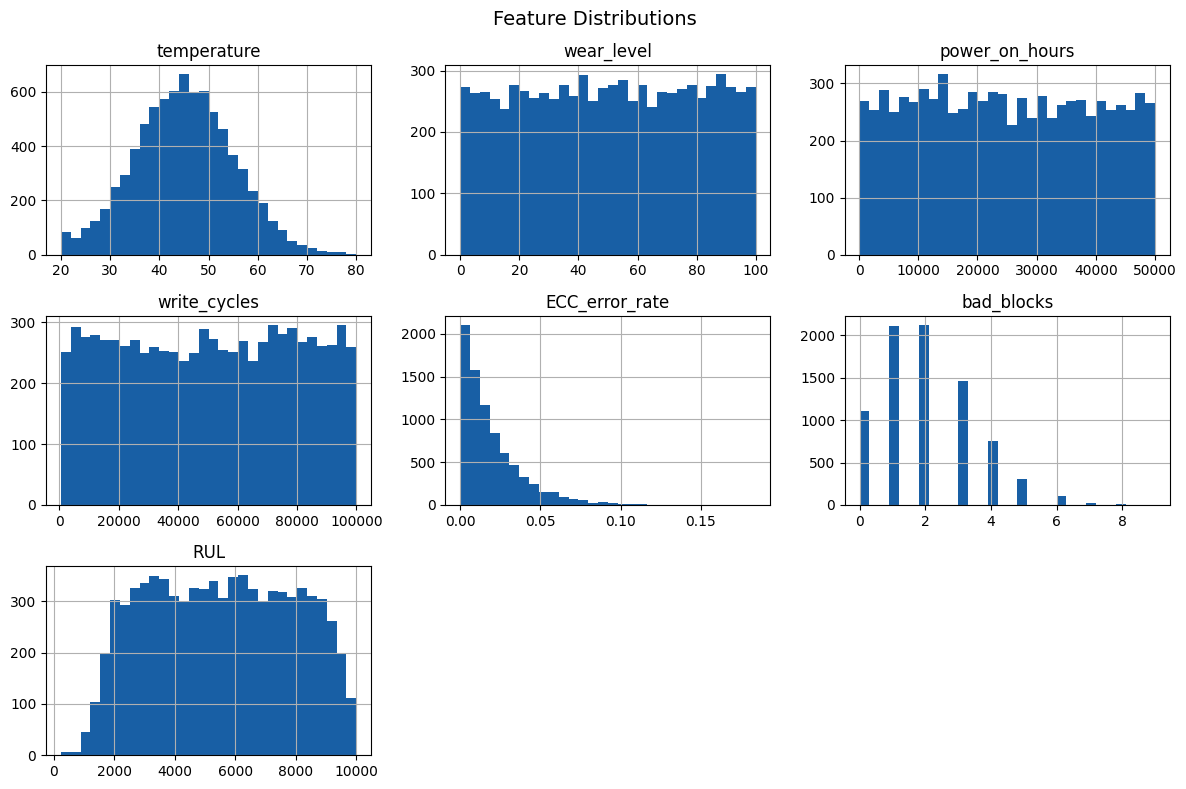

In [8]:
df.drop(columns=["health_status"]).hist(
    figsize=(12, 8),
    bins=30,
    color="#185FA5"
)

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/feature_histograms.png", dpi=150)
plt.show()

In [ ]:
## Feature Distribution Insight

- Temperature is fairly normally distributed around ~45°C.
- ECC error rate is highly skewed, indicating most SSDs have low errors.
- Bad blocks are mostly low, with few extreme cases.
- Wear level is evenly distributed across the range.
    

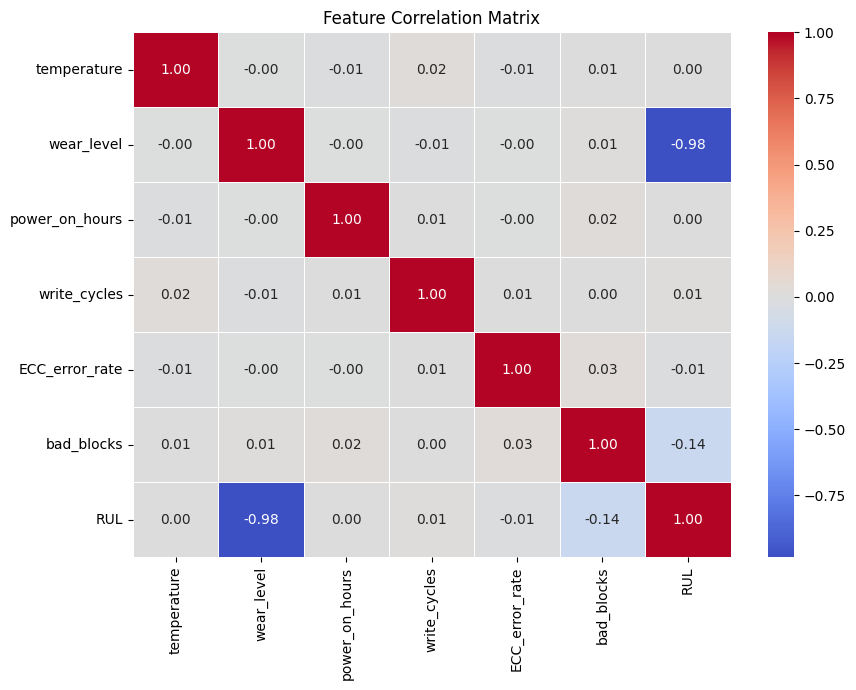

In [9]:
plt.figure(figsize=(9, 7))

corr = df.drop(columns=["health_status"]).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
## Correlation Insight

- Wear level shows strong relationship with RUL.
- Bad blocks and ECC error rate are positively correlated with degradation.
- Power-on hours correlates with increased wear and reduced RUL.
- Temperature shows mild correlation with SSD health indicators.

In [ ]:
## Final EDA Summary

The dataset represents SSD health behavior across usage and failure conditions.

Key observations:
- SSDs mostly fall under Warning/Healthy states, with few Critical cases.
- Wear level, bad blocks, and ECC error rate are strong indicators of degradation.
- Increased usage (power_on_hours, write_cycles) leads to higher wear and lower RUL.
- The dataset is suitable for both classification (health_status) and regression (RUL).